# Feature Engineering

This notebook creates higher-level, interpretable features from the preprocessed dataset.
The goal is to derive regime/state representations (macro, fundamentals, technicals) and verify their coherence before target construction.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

IN_PREP_PATH = "../data/processed/financial_database_preprocessed.parquet"
OUT_FEAT_PATH = "../data/processed/financial_database_features.parquet"

## Load preprocessed dataset

We load the preprocessed dataset produced in the previous step.
All feature engineering is performed on this stabilized dataset to ensure consistency and reproducibility.


In [ ]:
df_prep = pd.read_parquet(IN_PREP_PATH)
print("Shape:", df_prep.shape)
display(df_prep.head(3))

Shape: (27650, 37)


,date,open,high,low,close,adj_close,volume,sma_50,sma_200,ema_20,price_sma_50,rsi_14,macd,macd_signal,volatility_20d,ret_1d,ret_5d,ret_21d,net_margin,operating_margin,ebitda_margin,asset_turnover,roe,roa,fcf_margin,revenue_growth_qoq,earnings_growth_qoq,fcf_growth_qoq,debt_to_equity,current_ratio,effective_date,macro_effective_date,CPIAUCSL,FEDFUNDS,GDP,ticker,log_volume
0,2015-01-02,27.847500,27.860001,26.837500,27.332500,24.237553,212818400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.201007,0.265057,0.321819,0.181691,0.074765,0.036470,0.223109,0.123996,0.092798,0.201176,0.316414,1.012057,2014-11-29,2015-01-01,NaN,0.11,NaN,AAPL,19.175950
1,2015-01-02,15.629000,15.737500,15.348000,15.426000,15.426000,55664000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.021235,-0.026435,0.027455,0.489650,-0.042279,-0.010812,0.018854,0.064064,2.000000,-0.500000,0.383417,0.891085,2014-11-29,2015-01-01,NaN,0.11,NaN,AMZN,17.834844
2,2015-01-02,26.629999,26.790001,26.393999,26.477501,26.278944,26480000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.165769,0.225383,0.328572,0.131363,0.027718,0.021776,0.216486,0.035600,-0.182632,0.199933,0.053018,4.470703,2014-11-29,2015-01-01,NaN,0.11,NaN,GOOGL,17.091900


## Feature set to be created

We create a compact set of interpretable features:

- **Macro**: trend indicators and a 4-state macro regime.
- **Fundamentals**: cross-sectional buckets (low/mid/high) and simple binary flags.
- **Technicals**: RSI state and a long-term trend state.

The objective is to enrich the dataset with higher-level representations while keeping the feature set small and interpretable.


## Generate engineered features

We apply the feature engineering function to the preprocessed dataset.
The original features are retained and new columns are appended.


In [8]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.preprocessing.features_engineering import engineer_features

df_feat = engineer_features(df_prep)

print("Preprocessed shape:", df_prep.shape)
print("With engineered features:", df_feat.shape)
display(df_feat.head(3))


Preprocessed shape: (27650, 37)
With engineered features: (27650, 49)


,date,open,high,low,close,adj_close,volume,sma_50,sma_200,ema_20,price_sma_50,rsi_14,macd,macd_signal,volatility_20d,ret_1d,ret_5d,ret_21d,net_margin,operating_margin,ebitda_margin,asset_turnover,roe,roa,fcf_margin,revenue_growth_qoq,earnings_growth_qoq,fcf_growth_qoq,debt_to_equity,current_ratio,effective_date,macro_effective_date,CPIAUCSL,FEDFUNDS,GDP,ticker,log_volume,cpi_trend,rate_trend,gdp_trend,macro_regime,margin_bucket,profitability_bucket,leverage_bucket,is_profitable,is_high_growth,is_high_leverage,rsi_state,trend_state
0,2015-01-02,27.847500,27.860001,26.837500,27.332500,24.237553,212818400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.201007,0.265057,0.321819,0.181691,0.074765,0.036470,0.223109,0.123996,0.092798,0.201176,0.316414,1.012057,2014-11-29,2015-01-01,NaN,0.11,NaN,AAPL,19.175950,0,0,0,recession,high,high,mid,1,1,1,0,<NA>
1,2015-01-02,15.629000,15.737500,15.348000,15.426000,15.426000,55664000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.021235,-0.026435,0.027455,0.489650,-0.042279,-0.010812,0.018854,0.064064,2.000000,-0.500000,0.383417,0.891085,2014-11-29,2015-01-01,NaN,0.11,NaN,AMZN,17.834844,0,0,0,recession,low,low,high,0,1,1,0,<NA>
2,2015-01-02,26.629999,26.790001,26.393999,26.477501,26.278944,26480000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.165769,0.225383,0.328572,0.131363,0.027718,0.021776,0.216486,0.035600,-0.182632,0.199933,0.053018,4.470703,2014-11-29,2015-01-01,NaN,0.11,NaN,GOOGL,17.091900,0,0,0,recession,mid,low,low,1,0,0,0,<NA>


## New feature columns

We define the list of engineered features and use it consistently across validation checks.


In [9]:
new_cols = [
    "cpi_trend", "rate_trend", "gdp_trend", "macro_regime",
    "margin_bucket", "profitability_bucket", "leverage_bucket",
    "is_profitable", "is_high_growth", "is_high_leverage",
    "rsi_state", "trend_state"
]

missing_new = [c for c in new_cols if c not in df_feat.columns]
print("Missing engineered columns:", missing_new)


Missing engineered columns: []


## Validation: missing values in engineered features

We check the missing value rates of the new features.
Most engineered variables should be fully populated, while some NaNs are expected for trend-related features during the initial warm-up period (e.g., SMA200-based trend state).

In [10]:
display(df_feat[new_cols].isna().mean().sort_values(ascending=False))

trend_state             0.072333
leverage_bucket         0.015949
cpi_trend               0.000000
rate_trend              0.000000
gdp_trend               0.000000
macro_regime            0.000000
margin_bucket           0.000000
profitability_bucket    0.000000
is_profitable           0.000000
is_high_growth          0.000000
is_high_leverage        0.000000
rsi_state               0.000000
dtype: float64

## Validation: macro regime coherence

We inspect the distribution of macro regimes and trend indicators.
A reasonable regime distribution and temporal stability support the interpretability of the macro representation.


In [17]:
display(df_feat["macro_regime"].value_counts(dropna=False))
display(df_feat["cpi_trend"].value_counts(dropna=False).sort_index())
display(df_feat["rate_trend"].value_counts(dropna=False).sort_index())
display(df_feat["gdp_trend"].value_counts(dropna=False).sort_index())

macro_regime
expansion      24110
recession       2620
stagflation      920
Name: count, dtype: int64

cpi_trend
0     2620
1    25030
Name: count, dtype: int64

rate_trend
-1     7750
 0     1260
 1    18640
Name: count, dtype: int64

gdp_trend
-1      630
 0     2910
 1    24110
Name: count, dtype: int64

## Validation: fundamentals buckets and flags

We verify that cross-sectional buckets are reasonably balanced and that binary flags are not degenerate (always 0 or always 1).

In [12]:
display(df_feat["margin_bucket"].value_counts(dropna=False))
display(df_feat["profitability_bucket"].value_counts(dropna=False))
display(df_feat["leverage_bucket"].value_counts(dropna=False))

display(df_feat["is_profitable"].value_counts(dropna=False))
display(df_feat["is_high_growth"].value_counts(dropna=False))
display(df_feat["is_high_leverage"].value_counts(dropna=False))


margin_bucket
high    11060
low      8295
mid      8295
Name: count, dtype: int64

profitability_bucket
high    11060
low      8295
mid      8295
Name: count, dtype: int64

leverage_bucket
high    10619
low      8295
mid      8295
NaN       441
Name: count, dtype: int64

is_profitable
1    25744
0     1906
Name: count, dtype: int64

is_high_growth
1    13825
0    13825
Name: count, dtype: int64

is_high_leverage
0    14266
1    13384
Name: count, dtype: int64

## Validation: technical states

We verify that technical states are plausible (e.g., RSI state distribution) and inspect the long-term trend state derived from price vs SMA200.


In [13]:
display(df_feat["rsi_state"].value_counts(dropna=False).sort_index())
display(df_feat["trend_state"].value_counts(dropna=False))

rsi_state
-1     2174
 0    20298
 1     5178
Name: count, dtype: int64

trend_state
1       18844
0        6806
<NA>     2000
Name: count, dtype: Int64

## Quick inspection on a single ticker

We inspect a single ticker over time to ensure that engineered features evolve coherently.
This is a qualitative sanity check to catch implementation mistakes early.

In [14]:
ticker = "AAPL"
cols_show = ["date", "ticker"] + new_cols + ["net_margin", "roe", "debt_to_equity", "rsi_14", "adj_close", "sma_200"]

tmp = df_feat[df_feat["ticker"] == ticker].sort_values("date")
display(tmp[cols_show].tail(25))


,date,ticker,cpi_trend,rate_trend,gdp_trend,macro_regime,margin_bucket,profitability_bucket,leverage_bucket,is_profitable,is_high_growth,is_high_leverage,rsi_state,trend_state,net_margin,roe,debt_to_equity,rsi_14,adj_close,sma_200
27400,2025-11-24,AAPL,1,-1,1,expansion,mid,high,high,1,0,1,0,1,0.249202,0.347688,1.544858,55.138574,275.920013,225.819773
27410,2025-11-25,AAPL,1,-1,1,expansion,mid,high,high,1,0,1,0,1,0.249202,0.347688,1.544858,60.332919,276.970001,226.066347
27420,2025-11-26,AAPL,1,-1,1,expansion,mid,high,high,1,0,1,0,1,0.249202,0.347688,1.544858,61.561762,277.549988,226.316826
27430,2025-11-28,AAPL,1,-1,1,expansion,mid,high,high,1,0,1,0,1,0.249202,0.347688,1.544858,63.020713,278.850006,226.545440
27440,2025-12-01,AAPL,1,-1,1,expansion,mid,high,high,1,1,1,0,1,0.268050,0.362729,1.523509,67.228000,283.100006,226.759376
27450,2025-12-02,AAPL,1,-1,1,expansion,mid,high,high,1,1,1,1,1,0.268050,0.362729,1.523509,70.156314,286.190002,226.971342
27460,2025-12-03,AAPL,1,-1,1,expansion,mid,high,high,1,1,1,0,1,0.268050,0.362729,1.523509,67.543305,284.149994,227.183459
27470,2025-12-04,AAPL,1,-1,1,expansion,mid,high,high,1,1,1,0,1,0.268050,0.362729,1.523509,66.984720,280.700012,227.386025
27480,2025-12-05,AAPL,1,-1,1,expansion,mid,high,high,1,1,1,0,1,0.268050,0.362729,1.523509,61.274369,278.779999,227.569347
27490,2025-12-08,AAPL,1,-1,1,expansion,mid,high,high,1,1,1,0,1,0.268050,0.362729,1.523509,58.909084,277.890015,227.738286


## Optional visualization

To visually validate the technical trend state, we plot price and SMA200 for one ticker.

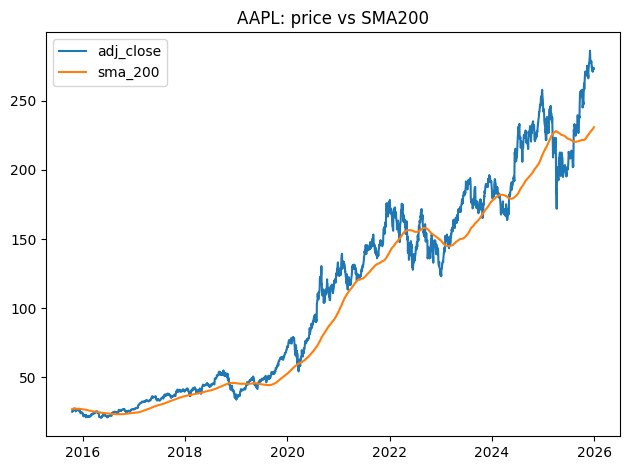

In [15]:
tmp2 = tmp.dropna(subset=["sma_200"]).copy()

plt.figure()
plt.plot(tmp2["date"], tmp2["adj_close"], label="adj_close")
plt.plot(tmp2["date"], tmp2["sma_200"], label="sma_200")
plt.title(f"{ticker}: price vs SMA200")
plt.legend()
plt.tight_layout()
plt.show()

## Save engineered dataset

We save the engineered dataset as a separate Parquet artifact.
This file will be used as the input for target construction and subsequent modeling stages.

In [16]:
df_feat.to_parquet(OUT_FEAT_PATH, index=False)
print("Saved:", OUT_FEAT_PATH)

Saved: ../data/processed/financial_database_features.parquet
